In [1]:
# Imports
from functools import partial

import jax
import optax
from flax import nnx
from helper import DataLoader
from jax import numpy as jnp
from jax import random, vmap

from matplotlib import pyplot as plt
from plotting import plot_prediction_with_uncertainty, plot_uncertainty_and_maximum
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

from laplax.curv import create_ggn_mv, create_posterior_fn
from laplax.eval.pushforward import (
    lin_pred_mean,
    lin_pred_std,
    lin_pred_var,
    lin_setup,
    set_lin_pushforward,
)

seed = 2392385

In [2]:
# Overview over active learning goal and procedure

In [3]:
# Data creation: Function that samples a y value given x
# and creates some small train set


def sample_target(x, key, sample_variance=0.0005):
    """Sample a target (label) for a given datapoint x.

    Args:
        x: x-value for which to sample a label
        key: PRNGKey to use for sampling
        sample_variance: Strength of added noise

    Returns:
        $y = f(x) + eps$ where $f$ is the sinc function
        and eps is Gaussian noise with mean zero and variance given by 'sample_variance'
    """
    x = x.squeeze()  # Assume one-dimensional x values
    y_true = jnp.sinc(x)
    noise = random.normal(key, y_true.shape) * jnp.sqrt(sample_variance)
    return y_true + noise


def true_function(xs):
    key = random.key(seed)
    keys = random.split(key, len(xs))

    function = partial(sample_target, sample_variance=0.0)
    return vmap(function)(xs, keys)


x = jnp.concatenate((jnp.linspace(0.2, 2, 2), jnp.linspace(3.5, 5, 2)))[:, None]

key = random.key(seed)
keys = random.split(key, len(x))

prior_variance = 0.01

sample = partial(sample_target, sample_variance=prior_variance)

y = vmap(sample)(x, keys)[:, None]

dataloader = DataLoader(x, y, batch_size=10)

In [4]:
# Model definition


class Model(nnx.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, rngs):
        self.linear1 = nnx.Linear(in_channels, hidden_channels, rngs=rngs)
        self.linear2 = nnx.Linear(hidden_channels, hidden_channels, rngs=rngs)
        self.linear3 = nnx.Linear(hidden_channels, hidden_channels, rngs=rngs)
        self.linear4 = nnx.Linear(hidden_channels, hidden_channels, rngs=rngs)
        self.linear5 = nnx.Linear(hidden_channels, out_channels, rngs=rngs)

    def __call__(self, x):
        x = nnx.tanh(self.linear1(x))
        x = nnx.tanh(self.linear2(x))
        x = nnx.tanh(self.linear3(x))
        x = nnx.tanh(self.linear4(x))
        return self.linear5(x)


model = Model(in_channels=1, hidden_channels=64, out_channels=1, rngs=nnx.Rngs(seed))


@nnx.jit
def train_step(model, optimizer, x, y):
    def loss_fn(model):
        y_pred = model(x)  # Call methods directly
        return jnp.sum((y_pred - y) ** 2)

    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(grads)  # Inplace updates

    return loss

In [5]:
def train_model(model, dataloader, n_epochs=1000, lr=1e-3):
    """Trains the given model on the data.

    Args:
        model: nnx.Module that represents the model, can be pretrained
        dataloader: Data on which to train
        n_epochs: Number of epochs to train for
        lr: learning rate for optimizer

    Returns:
        Trained model
    """
    optimizer = nnx.Optimizer(model, optax.adam(lr))

    # Train epoch
    for epoch in range(n_epochs):
        for x_batch, y_batch in dataloader:
            loss = train_step(model, optimizer, x_batch, y_batch)

        if epoch % 100 == 0:
            print(f"[epoch {epoch}]: loss: {loss:.4f}")
    print(f"Final loss: {loss:.4f}")
    return model


model = train_model(model, dataloader)

[epoch 0]: loss: 0.6701
[epoch 100]: loss: 0.0163
[epoch 200]: loss: 0.0074
[epoch 300]: loss: 0.0027
[epoch 400]: loss: 0.0000
[epoch 500]: loss: 0.0003
[epoch 600]: loss: 0.0000
[epoch 700]: loss: 0.0000
[epoch 800]: loss: 0.0000
[epoch 900]: loss: 0.0000
Final loss: 0.0001


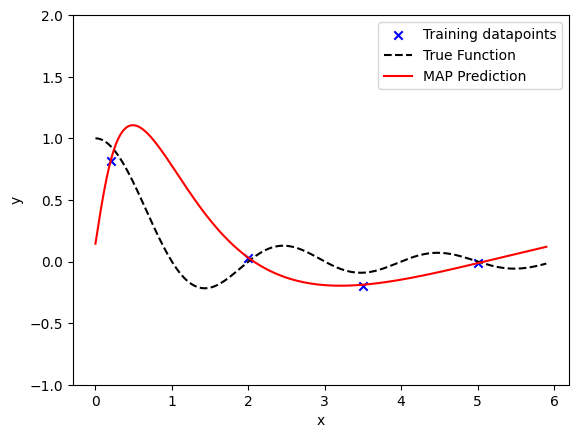

In [8]:
# Trained model visualization

x_pred = jnp.linspace(0.0, 5.9, 200)[:, None]

y_true = true_function(x_pred)
y_pred = model(x_pred)


fig, ax = plt.subplots()
plot_prediction_with_uncertainty(ax, dataloader, x_pred, y_true, y_pred, None)
plt.show()

In [ ]:
def quantify_uncertainty(model, trainloader, x_pred, prior_precision):
    """Compute uncertainty of model on x_pred using laplax.

    Args:
        model: Model whose uncertainty is to be quantified
        trainloader: Datapoints used for training of model
        x_pred: Points where to quantify uncertainty
        prior_precision: Precision of assumed prior

    Returns:
        Tuple of prediction and its uncertainty (standard deviation)
    """
    graph_def, params = nnx.split(model)

    def model_fn(input, params):
        return nnx.call((graph_def, params))(input)[0]

    trainset = {"input": trainloader.X, "target": trainloader.y}

    ggn_mv = create_ggn_mv(
        model_fn,
        params,
        trainset,
        loss_fn="mse",
    )

    posterior_fn = create_posterior_fn(
        curv_type="full",
        mv=ggn_mv,
        layout=params,
    )

    set_prob_predictive = partial(
        set_lin_pushforward,
        model_fn=model_fn,
        mean_params=params,
        posterior_fn=posterior_fn,
        pushforward_fns=[
            lin_setup,
            lin_pred_mean,
            lin_pred_var,
            lin_pred_std,
        ],
    )
    prior_arguments = {"prior_prec": prior_precision}
    prob_predictive = set_prob_predictive(
        prior_arguments=prior_arguments,
    )

    pred = jax.vmap(prob_predictive)(x_pred)
    y_mean = pred["pred_mean"][:, 0]
    y_std = jnp.sqrt(pred["pred_var"][:, 0])

    return y_mean, y_std


prior_precision = 1.0 / prior_variance

y_mean, y_std = quantify_uncertainty(model, dataloader, x_pred, prior_precision)

In [ ]:
def find_next_datapoint(x_pred, y_std):
    """Find the datapoint with largest uncertainty.

    Args:
        x_pred: Array of x values fo which uncertainty is known
        y_std: Uncertainty of x-values

    Returns:
        x-value with largest uncertainty
    """
    next_index = jnp.argmax(y_std)
    return x_pred[next_index]


next_datapoint = find_next_datapoint(x_pred, y_std)

In [ ]:
# Visualization with uncertainty, optimal next data point

fig, (ax1, ax2) = plt.subplots(2, sharex=True, figsize=(10,10))
plot_prediction_with_uncertainty(ax1, dataloader, x_pred, y_true, y_mean, y_std)
plot_uncertainty_and_maximum(ax2, x_pred, y_std, next_datapoint)
plt.show()

In [ ]:
# Active learning loop

learning_rounds = 15

key = random.key(21780)
keys = random.split(key, learning_rounds)

subplot1_data = []
subplot2_data = []

for key in keys:
    next_target = sample_target(next_datapoint, key)
    dataloader = dataloader.add(next_datapoint, next_target)
    train_model(model, dataloader, n_epochs=100)
    y_mean, y_std = quantify_uncertainty(model, dataloader, x_pred, prior_precision)
    subplot1_data.append((dataloader, x_pred, y_true, y_mean, y_std))

    next_datapoint = find_next_datapoint(x_pred, y_std)
    subplot2_data.append((x_pred, y_std, next_datapoint))



In [ ]:
fig, (ax1, ax2) = plt.subplots(2, sharex=True, figsize=(10,10))

def update(frame):
    ax1.clear()
    ax2.clear()
    artists1 = plot_prediction_with_uncertainty(ax1, *(subplot1_data[frame]))
    artists2 = plot_uncertainty_and_maximum(ax2, *(subplot2_data[frame]))
    return artists1 + artists2
    
animation = FuncAnimation(fig, update, frames=learning_rounds, interval=1500, repeat_delay=2000)
plt.close(fig)  # Prevent duplicate figure
HTML(animation.to_jshtml())